## Imports ##

In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import kagglehub

In [2]:
!pip install kagglehub

Defaulting to user installation because normal site-packages is not writeable


## Import Dataset ##

In [4]:
path = kagglehub.dataset_download("crowdflower/twitter-airline-sentiment")
print("Path to dataset files:", path)

100%|██████████| 2.55M/2.55M [00:00<00:00, 9.28MB/s]

Extracting files...
Path to dataset files: C:\Users\Jason Lee\.cache\kagglehub\datasets\crowdflower\twitter-airline-sentiment\versions\4


## Load ##

In [9]:
csv_path = os.path.join(path, "Tweets.csv")
df = pd.read_csv(csv_path)

print("Dataset shape:", df.shape)
print("Dataset columns:", df.columns)
print("First 5 rows of the dataset:")
print(df.head())

Dataset shape: (14640, 15)
Dataset columns: Index(['tweet_id', 'airline_sentiment', 'airline_sentiment_confidence',
       'negativereason', 'negativereason_confidence', 'airline',
       'airline_sentiment_gold', 'name', 'negativereason_gold',
       'retweet_count', 'text', 'tweet_coord', 'tweet_created',
       'tweet_location', 'user_timezone'],
      dtype='object')
First 5 rows of the dataset:
             tweet_id airline_sentiment  airline_sentiment_confidence  \
0  570306133677760513           neutral                        1.0000   
1  570301130888122368          positive                        0.3486   
2  570301083672813571           neutral                        0.6837   
3  570301031407624196          negative                        1.0000   
4  570300817074462722          negative                        1.0000   

  negativereason  negativereason_confidence         airline  \
0            NaN                        NaN  Virgin America   
1            NaN                

Identify key columns

In [12]:
text_col = "text"
target_col = "airline_sentiment"

print("Text column:", text_col)
print("Target column:", target_col)

Text column: text
Target column: airline_sentiment


Check class distribution

airline_sentiment
negative    9178
neutral     3099
positive    2363
Name: count, dtype: int64


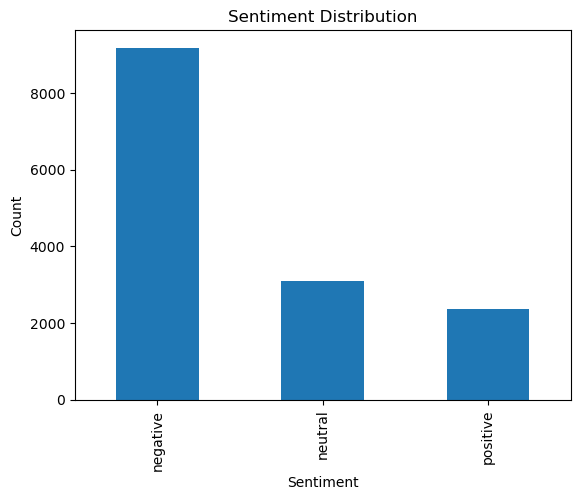

In [15]:
sentiment_counts = df[target_col].value_counts()

print(sentiment_counts)
sentiment_counts.plot(kind="bar")
plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.show()

Check missing Values

In [18]:
df.isnull().sum()

tweet_id                            0
airline_sentiment                   0
airline_sentiment_confidence        0
negativereason                   5462
negativereason_confidence        4118
airline                             0
airline_sentiment_gold          14600
name                                0
negativereason_gold             14608
retweet_count                       0
text                                0
tweet_coord                     13621
tweet_created                       0
tweet_location                   4733
user_timezone                    4820
dtype: int64

In [20]:
df[text_col].sample(10).tolist()

['@united You might be dealing with frustrated passenegers. hope you all have a great day :) thank you very much for an amazing airline :)',
 "@JetBlue how much longer to JFK open's I am a diabetic and I need sugar plane don't have nothing",
 "@united Do we know why UA5282 is delayed x2)? This is getting crazy. I've already had 2 overnight delays. #UnitedAirlines",
 "@SouthwestAir it's ok I was supposed to be in California 5hrs ago",
 '@united this is it... Last time I fly #UnitedAirlines  you screw up every trip now will be stuck in ord and miss work.',
 "@AmericanAir How am I supposed to Cancelled Flight it if I can't do it online?  I don't want to lose all the funds on the ticket.  HELP!!! :(",
 "@united Still do not have my bag, it's in the CLT airport. Was originally told I would have it by 2pm.",
 '@united Flight has been delayed for another hour so only have 24 mins to transit at LAX... Extremely unlikely I will make it!',
 '@VirginAmerica Will flights be leaving Dallas for LA o

Keeping the Necessary Columns

In [23]:
tweets = df[[text_col, target_col]].copy()
tweets.head()

,text,airline_sentiment
0,@VirginAmerica What @dhepburn said.,neutral
1,@VirginAmerica plus you've added commercials t...,positive
2,@VirginAmerica I didn't today... Must mean I n...,neutral
3,@VirginAmerica it's really aggressive to blast...,negative
4,@VirginAmerica and it's a really big bad thing...,negative


Checking duplicates

In [26]:
print("Before removing duplicates:", tweets.shape)

tweets = tweets.drop_duplicates()

print("After removing duplicates:", tweets.shape)

Before removing duplicates: (14640, 2)
After removing duplicates: (14452, 2)


Cleaning the tweet text

In [29]:
import re

def clean_text(text):
    text = text.lower()
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"@\w+", "", text)
    text = re.sub(r"#", "", text)
    text = re.sub(r"[^a-z\s]", "", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

tweets["clean_text"] = tweets[text_col].apply(clean_text)

tweets[[text_col, "clean_text"]].head(10)

,text,clean_text
0,@VirginAmerica What @dhepburn said.,what said
1,@VirginAmerica plus you've added commercials t...,plus youve added commercials to the experience...
2,@VirginAmerica I didn't today... Must mean I n...,i didnt today must mean i need to take another...
3,@VirginAmerica it's really aggressive to blast...,its really aggressive to blast obnoxious enter...
4,@VirginAmerica and it's a really big bad thing...,and its a really big bad thing about it
5,@VirginAmerica seriously would pay $30 a fligh...,seriously would pay a flight for seats that di...
6,"@VirginAmerica yes, nearly every time I fly VX...",yes nearly every time i fly vx this ear worm w...
7,@VirginAmerica Really missed a prime opportuni...,really missed a prime opportunity for men with...
8,"@virginamerica Well, I didn't…but NOW I DO! :-D",well i didntbut now i do d
9,"@VirginAmerica it was amazing, and arrived an ...",it was amazing and arrived an hour early youre...


Encoding sentiment labels

In [32]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
tweets["label"] = label_encoder.fit_transform(tweets[target_col])

print(label_encoder.classes_)
tweets[[target_col, "label"]].head()

['negative' 'neutral' 'positive']


,airline_sentiment,label
0,neutral,1
1,positive,2
2,neutral,1
3,negative,0
4,negative,0


Splitting into train and test

In [35]:
from sklearn.model_selection import train_test_split

X = tweets["clean_text"]
y = tweets["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=58,
    stratify=y
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

X_train shape: (11561,)
X_test shape: (2891,)


Tokenize and pad the text

In [38]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

max_words = 10000
max_len = 50

tokenizer = Tokenizer(num_words=max_words, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

X_train_pad = pad_sequences(X_train_seq, maxlen=max_len, padding="post", truncating="post")
X_test_pad = pad_sequences(X_test_seq, maxlen=max_len, padding="post", truncating="post")

print("X_train_pad shape:", X_train_pad.shape)
print("X_test_pad shape:", X_test_pad.shape)

X_train_pad shape: (11561, 50)
X_test_pad shape: (2891, 50)


## LSTM Model

In [56]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout

model = Sequential([
    Embedding(input_dim=max_words, output_dim=64),
    LSTM(64),
    Dropout(0.5),
    Dense(3, activation="softmax")
])

model.build(input_shape=(None, max_len))
model.summary()

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ (None, 50, 64)         │       640,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 673,219 (2.57 MB)

 Trainable params: 673,219 (2.57 MB)

 Non-trainable params: 0 (0.00 B)

## Compiling the model

In [58]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

## Adding Classs Weights to fix imbalance

In [73]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

classes = np.unique(y_train)
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train
)

class_weight_dict = dict(zip(classes, class_weights))
print(class_weight_dict)

{0: 0.5301508689870225, 1: 1.5703613148600923, 2: 2.096663039535727}


## Train the model

In [75]:
history = model.fit(
    X_train_pad,
    y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.2,
    class_weight=class_weight_dict
)

Epoch 1/10
289/289 ━━━━━━━━━━━━━━━━━━━━ 6s 17ms/step - accuracy: 0.9385 - loss: 0.2537 - val_accuracy: 0.7609 - val_loss: 0.8078
Epoch 2/10
289/289 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - accuracy: 0.9489 - loss: 0.2174 - val_accuracy: 0.7717 - val_loss: 0.7562
Epoch 3/10
289/289 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0.9613 - loss: 0.1719 - val_accuracy: 0.7367 - val_loss: 0.9983
Epoch 4/10
289/289 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0.9672 - loss: 0.1635 - val_accuracy: 0.7735 - val_loss: 0.8206
Epoch 5/10
289/289 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0.9720 - loss: 0.1318 - val_accuracy: 0.7618 - val_loss: 0.9728
Epoch 6/10
289/289 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0.9631 - loss: 0.1489 - val_accuracy: 0.7579 - val_loss: 1.0003
Epoch 7/10
289/289 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0.9439 - loss: 0.2083 - val_accuracy: 0.7601 - val_loss: 0.9981
Epoch 8/10
289/289 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0.9646 - loss: 0.1444 - val_accu

## Evaluating the model

In [77]:
test_loss, test_accuracy = model.evaluate(X_test_pad, y_test)
print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

91/91 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7437 - loss: 1.2682
Test Loss: 1.268244981765747
Test Accuracy: 0.7436873316764832


## Making Predictions

In [79]:
y_pred = model.predict(X_test_pad)
y_pred_classes = y_pred.argmax(axis=1)

91/91 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step


## Classification report

In [81]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_classes, target_names=label_encoder.classes_))

              precision    recall  f1-score   support

    negative       0.84      0.83      0.83      1818
     neutral       0.52      0.59      0.55       613
    positive       0.69      0.62      0.66       460

    accuracy                           0.74      2891
   macro avg       0.69      0.68      0.68      2891
weighted avg       0.75      0.74      0.75      2891



## Confustion Matrix

[[1502  252   64]
 [ 190  361   62]
 [  90   83  287]]


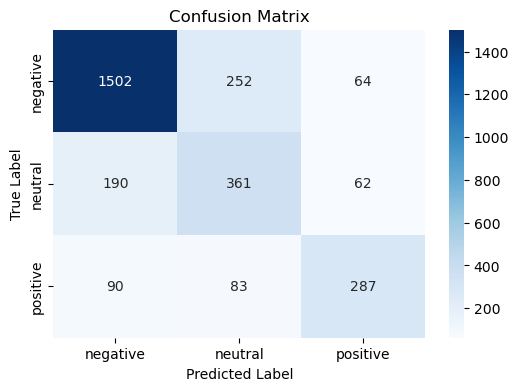

In [83]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, y_pred_classes)
print(cm)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)

plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

## Plotting training graphs

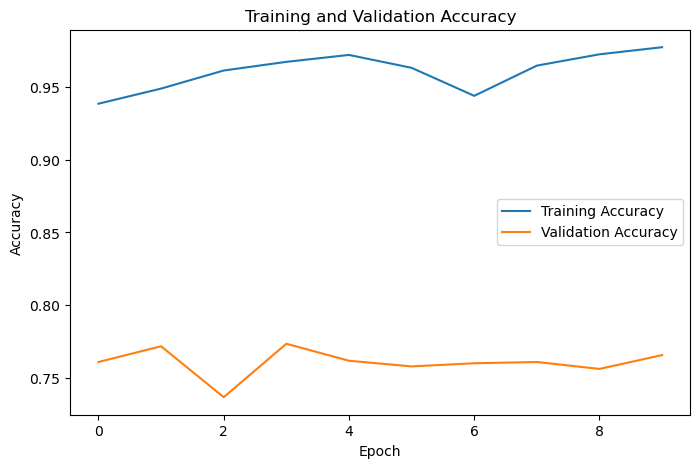

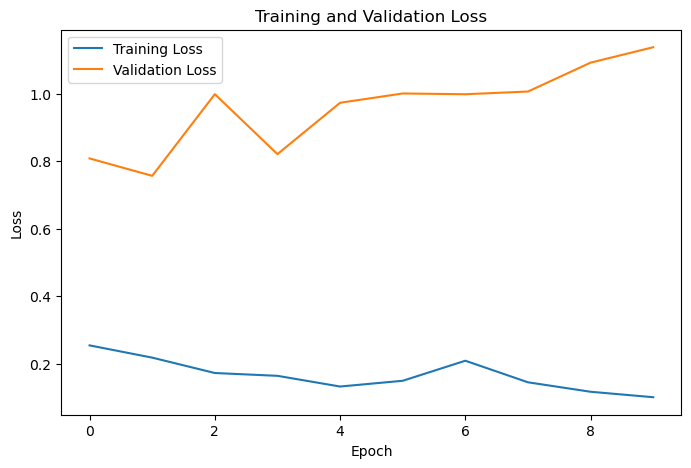

In [85]:
plt.figure(figsize=(8, 5))
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.title("Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()